### 훈련 데이터 준비


In [1]:
import urllib.request
import os

print("Andrej Karpathy의 원본 깃허브에서 'Tiny Shakespeare' 데이터를 직접 다운로드합니다...")

# 원본 텍스트 파일 URL
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"
file_name = "tiny_shakespeare.txt"

# 파일 다운로드 및 저장
urllib.request.urlretrieve(url, file_name)

# 저장 확인
if os.path.exists(file_name):
    with open(file_name, 'r', encoding='utf-8') as f:
        text_data = f.read()
    print(f"'{file_name}' 파일이 현재 경로에 성공적으로 저장되었습니다!")
    print(f"총 글자 수: {len(text_data):,}자")
else:
    print("다운로드에 실패했습니다.")

Andrej Karpathy의 원본 깃허브에서 'Tiny Shakespeare' 데이터를 직접 다운로드합니다...
'tiny_shakespeare.txt' 파일이 현재 경로에 성공적으로 저장되었습니다!
총 글자 수: 1,115,394자


In [2]:
import re

def clean_text(filename):
    with open(filename, 'r', encoding='utf-8') as file:
        book_text = file.read()
    cleaned_text = re.sub(r'\n+', ' ', book_text) # 줄바꿈을 빈칸으로 변경
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text) # 여러 빈칸을 하나의 빈칸으로 
    
    print("cleaned_" + filename, len(cleaned_text), "characters") # 글자 수 출력
    with open("cleaned_" + filename, 'w', encoding='utf-8') as file:
        file.write(cleaned_text)
        
filenames_list = ["tiny_shakespeare.txt"]

for filename in filenames_list:
    clean_text(filename)

cleaned_tiny_shakespeare.txt 1108153 characters


### 토큰화
UTF-8 BPE(Bype Pair Encoding)
-> tiktoken -> GPT모델과 똑같은 방식으로 데이터를 처리할 수 있어 학습 효율이 높음, Rust로 작성되어있어서 속도가 매우 빠름 

In [3]:
import tiktoken # pip install tiktoken -> 자주쓰는 토큰나이저

# GPT-2 방식의 토크나이저 불러오기
tokenizer = tiktoken.get_encoding("gpt2")

# 데이터셋에 맞춰 텍스트 변경 (셰익스피어 대본의 한 구절)
text = "First Citizen: Before we proceed any further, hear me speak."

# 인코드 -> 텍스트를 숫자로 바꿈 -> 아래 토큰 리스트 확인 
tokens = tokenizer.encode(text)

print("글자수:", len(text), "토큰수:", len(tokens))
print("토큰 리스트:", tokens)
# 디코드로 숫자 -> 문자열로 출력 
print("디코딩 결과:", tokenizer.decode(tokens))

print("-" * 30)
# 각 토큰을 디코드로 원본 문자열로 바꿔줌 
for t in tokens:
    print(f"{t}\t -> {tokenizer.decode([t])}")

글자수: 60 토큰수: 13
토큰 리스트: [5962, 22307, 25, 7413, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13]
디코딩 결과: First Citizen: Before we proceed any further, hear me speak.
------------------------------
5962	 -> First
22307	 ->  Citizen
25	 -> :
7413	 ->  Before
356	 ->  we
5120	 ->  proceed
597	 ->  any
2252	 ->  further
11	 -> ,
3285	 ->  hear
502	 ->  me
2740	 ->  speak
13	 -> .


In [4]:
# 실제로는 한 글자로 토큰화 안하지만 그냥 재미로 해본것. 
for char in text:
    token_ids = tokenizer.encode(char) # 한 글자씩 인코딩(토큰화)
    decoded = tokenizer.decode(token_ids) # 한 글자씩 디코딩
    print(f"{char} -> {token_ids} -> {decoded}")

F -> [37] -> F
i -> [72] -> i
r -> [81] -> r
s -> [82] -> s
t -> [83] -> t
  -> [220] ->  
C -> [34] -> C
i -> [72] -> i
t -> [83] -> t
i -> [72] -> i
z -> [89] -> z
e -> [68] -> e
n -> [77] -> n
: -> [25] -> :
  -> [220] ->  
B -> [33] -> B
e -> [68] -> e
f -> [69] -> f
o -> [78] -> o
r -> [81] -> r
e -> [68] -> e
  -> [220] ->  
w -> [86] -> w
e -> [68] -> e
  -> [220] ->  
p -> [79] -> p
r -> [81] -> r
o -> [78] -> o
c -> [66] -> c
e -> [68] -> e
e -> [68] -> e
d -> [67] -> d
  -> [220] ->  
a -> [64] -> a
n -> [77] -> n
y -> [88] -> y
  -> [220] ->  
f -> [69] -> f
u -> [84] -> u
r -> [81] -> r
t -> [83] -> t
h -> [71] -> h
e -> [68] -> e
r -> [81] -> r
, -> [11] -> ,
  -> [220] ->  
h -> [71] -> h
e -> [68] -> e
a -> [64] -> a
r -> [81] -> r
  -> [220] ->  
m -> [76] -> m
e -> [68] -> e
  -> [220] ->  
s -> [82] -> s
p -> [79] -> p
e -> [68] -> e
a -> [64] -> a
k -> [74] -> k
. -> [13] -> .


### 데이터 로더(DataLoader)

#### 반복문 안에 내용 -> for에서의 +1차이가 의미하는것
Text : Harry Potter was a Wizard <br>
input : Harry <br>
target :&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;Potter&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;-> Harry라 물어보면 Potter로 답해라. <br>

In [5]:
import torch
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, txt, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        token_ids = tokenizer.encode(txt)

        print("# of tokens in txt:", len(token_ids))

        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

with open("cleaned_tiny_shakespeare.txt", 'r', encoding='utf-8-sig') as file: # -sig를 붙여서 BOM 제거
    txt = file.read()

dataset = MyDataset(txt, max_length = 32, stride = 4)

train_loader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

# of tokens in txt: 294091


- 데이터로더가 어떻게 작동하는지 간단하게 보여줌.

In [6]:
dataiter = iter(train_loader)

x, y = next(dataiter)

# 위에 줄 (input)
print(tokenizer.decode(x[0].tolist()))
# 아래 줄 (target) -> 자세히 보면 한 단어씩 밀려서 보여지는게 보임 
print(tokenizer.decode(y[0].tolist()))

: The senators and patricians love him too: The tribunes are no soldiers; and their people Will be as rash in the repeal, as hasty
 The senators and patricians love him too: The tribunes are no soldiers; and their people Will be as rash in the repeal, as hasty To


#### 뉴럴네트워크 모델 정의


In [7]:
# 모델을 정의할 때 사용하는 상수들 

VOCAB_SIZE = tokenizer.n_vocab # 50257 Tiktoken
#VOCAB_SIZE = len(tokenizer) # AutoTokenizer
CONTEXT_LENGTH = 128  # Shortened context length (orig: 1024)
EMB_DIM = 768  # Embedding dimension
NUM_HEADS = 12  # Number of attention heads
NUM_LAYERS = 12  # Number of layers
DROP_RATE = 0.1  # Dropout rate
QKV_BIAS = False  # Query-key-value bias

In [8]:
import torch.nn as nn

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        
        assert d_out % NUM_HEADS == 0, "d_out must be divisible by n_heads"

        self.d_out = d_out
        self.head_dim = d_out // NUM_HEADS

        self.W_query = nn.Linear(d_in, d_out, bias=QKV_BIAS)
        self.W_key = nn.Linear(d_in, d_out, bias=QKV_BIAS)
        self.W_value = nn.Linear(d_in, d_out, bias=QKV_BIAS)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(DROP_RATE)
        self.register_buffer('mask', torch.triu(torch.ones(CONTEXT_LENGTH, CONTEXT_LENGTH), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, NUM_HEADS, self.head_dim)
        values = values.view(b, num_tokens, NUM_HEADS, self.head_dim)
        queries = queries.view(b, num_tokens, NUM_HEADS, self.head_dim)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)

        context_vec = context_vec.reshape(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()
        self.eps = 1e-5
        self.scale = nn.Parameter(torch.ones(emb_dim))
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        norm_x = (x - mean) / torch.sqrt(var + self.eps)
        return self.scale * norm_x + self.shift

class GELU(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x):
        return 0.5 * x * (1 + torch.tanh(
            torch.sqrt(torch.tensor(2.0 / torch.pi)) *
            (x + 0.044715 * torch.pow(x, 3))
        ))

class FeedForward(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(EMB_DIM, 4 * EMB_DIM),
            GELU(),
            nn.Linear(4 * EMB_DIM, EMB_DIM),
        )

    def forward(self, x):
        return self.layers(x)

class TransformerBlock(nn.Module):
    def __init__(self):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=EMB_DIM,
            d_out=EMB_DIM)
    
        self.ff = FeedForward()
        self.norm1 = LayerNorm(EMB_DIM)
        self.norm2 = LayerNorm(EMB_DIM)
        self.drop_shortcut = nn.Dropout(DROP_RATE)

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x


class GPTModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.tok_emb = nn.Embedding(VOCAB_SIZE, EMB_DIM)
        self.pos_emb = nn.Embedding(CONTEXT_LENGTH, EMB_DIM)
        self.drop_emb = nn.Dropout(DROP_RATE)

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock() for _ in range(NUM_LAYERS)])

        self.final_norm = LayerNorm(EMB_DIM)
        self.out_head = nn.Linear(EMB_DIM, VOCAB_SIZE, bias=False)

    def forward(self, in_idx):
        batch_size, seq_len = in_idx.shape
        tok_embeds = self.tok_emb(in_idx)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=in_idx.device))
        x = tok_embeds + pos_embeds  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

### 훈련 

In [9]:
import torch

# MPS 가속 설정 (애플 실리콘 전용)
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS가속을 사용합니다.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    print("GPU를 찾을 수 없어 CPU를 사용합니다.")

torch.manual_seed(123)
model = GPTModel()
model.to(device)

# 3. 최적화 도구 설정
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

MPS가속을 사용합니다.


In [10]:
tokens_seen, global_step = 0, -1
BATCH_SIZE = 128
Epochs = 6
losses = []

for epoch in range(Epochs):
    model.train() 
    
    epoch_loss = 0
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad() 
        input_batch, target_batch = input_batch.to(device), target_batch.to(device)

        logits = model(input_batch)
        loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
        epoch_loss += loss.item()
        loss.backward() 
        optimizer.step() 
        tokens_seen += input_batch.numel()
        global_step += 1

        if global_step % 1000 == 0:
            print(f"Tokens seen: {tokens_seen}")

    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch: {epoch + 1}, Loss: {avg_loss}")
    torch.save(model.state_dict(), "model_" + str(epoch + 1).zfill(3) + ".pth")

Tokens seen: 4096
Epoch: 1, Loss: 4.677962420294094
Tokens seen: 4100096
Epoch: 2, Loss: 2.2980352689995582
Epoch: 3, Loss: 0.7514405264048626
Tokens seen: 8196096
Epoch: 4, Loss: 0.42986429729320447
Epoch: 5, Loss: 0.3505597306149347
Tokens seen: 12292096
Epoch: 6, Loss: 0.31619176476259264


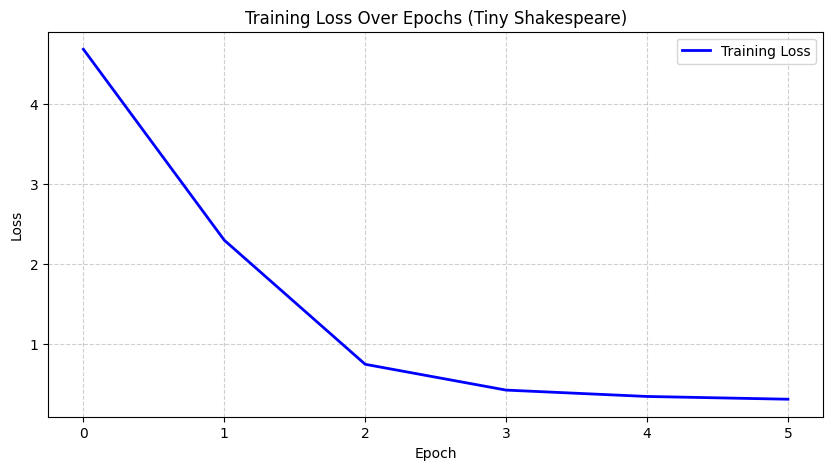

In [11]:
import matplotlib.pyplot as plt

# 그래프 크기와 해상도 조절 (맥 레티나 디스플레이에 최적화)
plt.figure(figsize=(10, 5), dpi=100) 

plt.plot(losses, label='Training Loss', color='blue', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs (Tiny Shakespeare)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6) # 격자 추가로 가독성 향상
plt.show()

In [16]:
# 1. 테스트 문구를 셰익스피어 대본 형식으로 변경 (예: "ROMEO:", "JULIET:", "To be,")
idx = tokenizer.encode("ROMEO:") # encode 후에 python list형태임 -> CPU RAM에 존재 
idx = torch.tensor(idx).unsqueeze(0).to(device) 
# 1.리스트 -> Tensor 변환 2.Batch단위로 데이터를 받음 -> 1차원을 2차원으로 만들어서 배치사이즈 1로 알려줌 -> VRAM으로 이동
print(idx)
print(tokenizer.decode([7900, 12689]))
# 2. 기울기 계산 비활성화 (추론 모드)
with torch.no_grad():
    logits = model(idx)

# 3. 마지막 타임스텝의 결과값만 추출
logits = logits[:, -1, :]
print(logits.shape)
print(logits)

# 4. 가장 확률이 높은 단어 10개 출력 (모델이 "ROMEO:" 다음에 올 단어로 뭘 고민하는지 확인)
top_logits, top_indices = torch.topk(logits, 10) 
print("--- Top 10 Candidates ---")
for p, i in zip(top_logits.squeeze(0).tolist(), top_indices.squeeze(0).tolist()):
    print(f"{p:.2f}\t {i}\t '{tokenizer.decode([i])}'")

# 5. 가장 확률이 높은 단어 최종 선택 (Argmax)
idx_next = torch.argmax(logits, dim=-1, keepdim=True)
flat = idx_next.squeeze(0) 
out = tokenizer.decode(flat.tolist()) 

print(f"\n최종 선택된 다음 단어: '{out}'")

tensor([[33676,  4720,    25]], device='mps:0')
 Ah Peace
torch.Size([1, 50257])
tensor([[ 0.6712, -4.4437, -4.1524,  ..., -3.6019, -2.9651, -3.6849]],
       device='mps:0')
--- Top 10 Candidates ---
13.21	 632	 ' It'
11.27	 317	 ' A'
11.04	 314	 ' I'
10.94	 1406	 ' So'
10.92	 37106	 ' Courage'
10.83	 3894	 ' Well'
10.61	 34048	 ' Thou'
10.50	 770	 ' This'
10.43	 13709	 ' Ay'
10.17	 1318	 ' There'

최종 선택된 다음 단어: ' It'


In [13]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

In [ ]:
start_context = input("Start context: ") # First Citizen 을 입력함. 

idx = tokenizer.encode(start_context)
idx = torch.tensor(idx).unsqueeze(0)

context_size = model.pos_emb.weight.shape[0] 

for i in range(10):

    token_ids = generate(
        model=model,
        idx=idx.to(device),
        max_new_tokens=50,
        context_size= context_size,
        top_k=50,
        temperature=0.5
    )

    flat = token_ids.squeeze(0)
    out = tokenizer.decode(flat.tolist()).replace("\n", " ")

    print(i, ":", out)

0 : First Citizen: He has done nobly, and cannot go without any honest man's voice. Seventh Citizen: Therefore let him be consul: the gods give him be't so good people. Second Citizen: and give him joys that will not! Clown
1 : First Citizen: Before we proceed any further, hear me speak. All: Speak, speak. First Citizen: You are all resolved rather to die than to famish? All: All: You seem to famish him, my quick, my study, my
2 : First Citizen: Before we proceed any further, hear me speak. All: Speak, speak. First Citizen: You are all resolved rather to die than to famish? Your grace and your highness; for this place i'ld-morrow morning'st
3 : First Citizen: No,'twas never my desire yet to trouble the poor with begging. Third Citizen: You must think, if we give you any thing, we hope to make known to be left aught insulting. MENENIUS: so secret,
4 : First Citizen: Before we proceed any further, hear me speak. All: Speak, speak. 'Tis time to speak; my pains are quite forgot. QUEENESTER